In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/LoanStatusPrediction.csv')

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [6]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
df.shape

(45000, 14)

In [8]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cols = ['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
for col in cols:
  df[col] = le.fit_transform(df[col])

{'whiskers': [<matplotlib.lines.Line2D at 0x7b9154de5a90>,
 'caps': [<matplotlib.lines.Line2D at 0x7b9154de6120>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b9154dd61b0>,
 'medians': [<matplotlib.lines.Line2D at 0x7b9154de67b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7b9154de6b10>,
 'means': []}

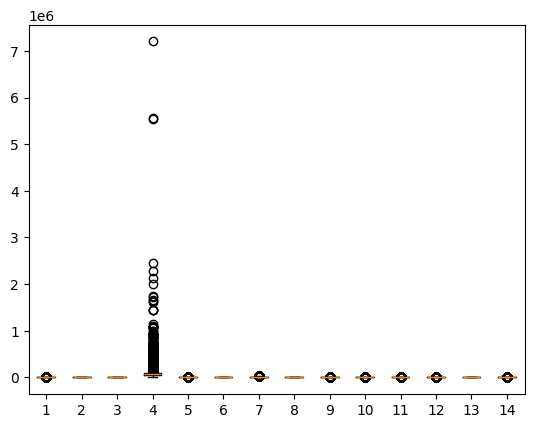

In [11]:
plt.boxplot(df)

In [12]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [13]:
from scipy.stats.mstats import winsorize
cols = ['person_age','person_emp_exp','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length','credit_score','loan_status']
for col in cols:
  df[col] = winsorize(df[col],limits = [0,0.1])

In [14]:
from scipy.stats import zscore
z = zscore(df)
df[np.abs(z)>3]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
15,23.0,0,4,600891.0,5,0,19200.0,0,10.65,0.05,3.0,670,1,0
33,25.0,0,3,368115.0,3,3,19200.0,0,13.85,0.07,3.0,567,1,0
34,26.0,0,0,361076.0,1,0,7800.0,3,13.49,0.02,4.0,669,0,0
42,26.0,1,1,361293.0,5,0,19200.0,5,7.88,0.06,4.0,684,1,0
43,23.0,1,3,361547.0,0,2,19200.0,1,14.97,0.07,2.0,637,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44557,35.0,1,4,483809.0,13,0,19200.0,3,11.76,0.06,10.0,619,0,1
44676,24.0,0,0,37217.0,1,3,5000.0,1,12.95,0.13,2.0,462,0,1
44922,29.0,1,4,726416.0,7,0,19200.0,3,9.07,0.03,9.0,634,0,1
44947,35.0,1,2,705960.0,13,0,19200.0,4,10.74,0.03,11.0,689,0,1


In [15]:
x = df.drop('loan_status',axis = 1)
y = df['loan_status']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,r2_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('R2Score:',r2_score(y_test, y_pred))

Accuracy: 0.8853333333333333
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      6990
           1       0.75      0.73      0.74      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.83      9000
weighted avg       0.88      0.89      0.88      9000

R2Score: 0.33892767920056344
